<a href="https://colab.research.google.com/github/andersonmoraix/analisedeconjuntura_anotacoes/blob/main/aula11_analisedeeconomiainternacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas

In [ ]:
# Instalar bibliotecas
!pip install plotnine
!pip install dbnomics #para ler a API do dbnomics

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Importar bibliotecas
import dbnomics #para ler a API do dbnomics
import pandas as pd
import plotnine

# Coleta de dados

In [ ]:
# Importa dados da OCDE pela API da DBNOMICS

# PIB
dados_brutos_pib = dbnomics.fetch_series_by_api_link(
    "https://api.db.nomics.world/v22/series/OECD/MEI?dimensions=%7B%22LOCATION" +
    "%22%3A%5B%22BRA%22%2C%22USA%22%2C%22CHN%22%2C%22CHL%22%2C%22ARG%22%2C%22E" +
    "A19%22%5D%2C%22SUBJECT%22%3A%5B%22NAEXKP01%22%5D%2C%22MEASURE%22%3A%5B%22" +
    "GPSA%22%5D%2C%22FREQUENCY%22%3A%5B%22Q%22%5D%7D&observations=1"
    )

# Desemprego
dados_brutos_desemprego = dbnomics.fetch_series_by_api_link(
    "https://api.db.nomics.world/v22/series/OECD/MEI?dimensions=%7B%22LOCATION" +
    "%22%3A%5B%22BRA%22%2C%22USA%22%2C%22CHN%22%2C%22CHL%22%2C%22ARG%22%2C%22E" +
    "A19%22%5D%2C%22SUBJECT%22%3A%5B%22LRHUTTTT%22%5D%2C%22MEASURE%22%3A%5B%22" +
    "STSA%22%5D%2C%22FREQUENCY%22%3A%5B%22M%22%5D%7D&observations=1"
    )

# Inflação
dados_brutos_inflacao = dbnomics.fetch_series_by_api_link(
    "https://api.db.nomics.world/v22/series/OECD/MEI?dimensions=%7B%22LOCATION" +
    "%22%3A%5B%22BRA%22%2C%22USA%22%2C%22CHN%22%2C%22CHL%22%2C%22ARG%22%2C%22E" +
    "A19%22%5D%2C%22SUBJECT%22%3A%5B%22CPALTT01%22%5D%2C%22MEASURE%22%3A%5B%22" +
    "GP%22%5D%2C%22FREQUENCY%22%3A%5B%22M%22%5D%7D&observations=1"
    )

# Juros
dados_brutos_juros = dbnomics.fetch_series_by_api_link(
    "https://api.db.nomics.world/v22/series/OECD/MEI?dimensions=%7B%22LOCATION" +
    "%22%3A%5B%22BRA%22%2C%22USA%22%2C%22CHN%22%2C%22CHL%22%2C%22ARG%22%2C%22E" +
    "A19%22%5D%2C%22SUBJECT%22%3A%5B%22IRSTCI01%22%5D%2C%22MEASURE%22%3A%5B%22" +
    "ST%22%5D%2C%22FREQUENCY%22%3A%5B%22M%22%5D%7D&observations=1"
    )

# Tratamento de dados

In [ ]:
# Empilhar as tabela
dados = (
    pd.concat( #funcao que junta as tabelas
    [dados_brutos_pib, dados_brutos_inflacao,
     dados_brutos_juros, dados_brutos_desemprego]
     )
    .rename(
        columns = {
            "period": "data",
            "Country": "pais",
            "SUBJECT": "variavel",
            "value": "valor"
            }
            )
    .filter(items = ["data", "pais", "variavel", "valor"])
    .replace(
        to_replace = {
            "variavel": {
                "NAEXKP01": "PIB (Var. % T/T)",
                "LRHUTTTT": "Desemprego (harmonizada, %, total)",
                "CPALTT01": "Inflação (Var. % M/M, total)",
                "IRSTCI01": "Juros (%, interbancária)"
            }
        }
    )
)
dados

,data,pais,variavel,valor
0,1996-04-01,Brazil,PIB (Var. % T/T),1.143340
1,1996-07-01,Brazil,PIB (Var. % T/T),3.721358
2,1996-10-01,Brazil,PIB (Var. % T/T),-0.959006
3,1997-01-01,Brazil,PIB (Var. % T/T),1.046952
4,1997-04-01,Brazil,PIB (Var. % T/T),0.534601
...,...,...,...,...
810,2022-07-01,United States,"Desemprego (harmonizada, %, total)",3.500000
811,2022-08-01,United States,"Desemprego (harmonizada, %, total)",3.700000
812,2022-09-01,United States,"Desemprego (harmonizada, %, total)",3.500000
813,2022-10-01,United States,"Desemprego (harmonizada, %, total)",3.700000


# Visualização dados

/usr/local/lib/python3.8/dist-packages/plotnine/facets/facet.py:390: PlotnineWarning: If you need more space for the x-axis tick text use ... + theme(subplots_adjust={'wspace': 0.25}). Choose an appropriate value for 'wspace'.
/usr/local/lib/python3.8/dist-packages/plotnine/facets/facet.py:396: PlotnineWarning: If you need more space for the y-axis tick text use ... + theme(subplots_adjust={'hspace': 0.25}). Choose an appropriate value for 'hspace'


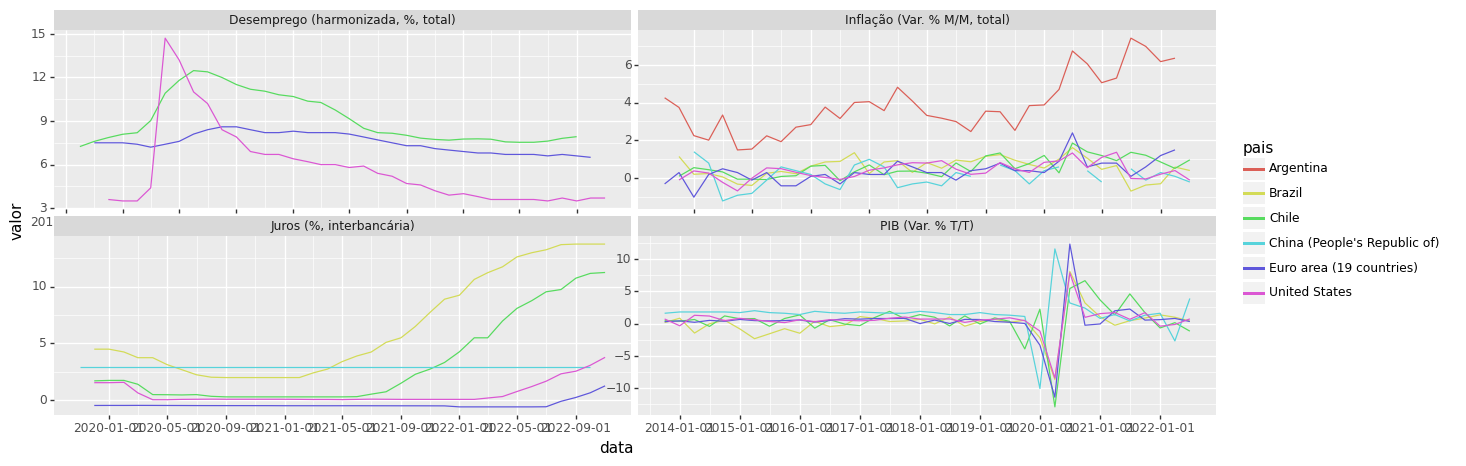

<ggplot: (8737231788596)>

In [ ]:
# Gráfico de linha
plotnine.options.figure_size = (15, 5)
(
    plotnine.ggplot(data = dados.groupby(["pais", "variavel"]).tail(36)) +
    plotnine.aes(x = "data", y = "valor", color = "pais") +
    plotnine.geom_line() +
    plotnine.facet_wrap(facets = "~variavel", scales = "free")
)